In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

import sys
sys.path.append("..")
from helper_functions_260527 import import_flight_data

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

pd.set_option('display.max_columns',None)

radio_altitude = "radio_altitude"
vertical_acceleration = "vert_acc"

recompute = True
limit = 1000

In [37]:
# Step 1: Define turbulence data (= labels) ✓
# Step 2: Prepare wind data (= features) ✓
# Step 3: Join flight and wind data
# Step 4: ML model
# Step 5: Input feature ranking

### Step 1: Define turbulence data (= labels)

In [ ]:
def trim_group(g):
    g = g.sort_values("Time (secs)")
    
    # find first index where altitude becomes valid
    valid_idx = g.index[g["radio_altitude"] > 1400]
    
    if len(valid_idx) == 0:
        return g.iloc[0:0]
    
    start = valid_idx[0]
    return g.loc[start:]

if recompute:
    path_flights = "/home/itz/AppML/FinalProject/Final_project_data/data/ML_data/NBI/FDM data/"
    df = import_flight_data(data_dir=path_flights,limit=limit,add_source_file=True,filter=False)

    # Remove everything where Radio Altitude > 1500 ft or below 0
    df[radio_altitude] = df[radio_altitude].ffill()
    df = df[df[radio_altitude] <= 1500]
    df = df[df[radio_altitude] >= 0]

    # For easier bookkeeping
    df["landing_id"] = pd.factorize(df["source_file"])[0]
    df = df.drop(["source_file"],axis=1)

    # Remove erroneous data points
    #df = df.groupby("landing_id", group_keys=False).apply(trim_group)
    df = df.reset_index(drop=True)

    # Calculate how much vertical accelaration deviates from 1
    df['vert_acc_dev'] = abs(df['vert_acc'] - 1.0)

    # Calculate std per landing
    turbulence_per_landing = df.groupby("landing_id")["vert_acc_dev"].std()

    show_extras = False
    if show_extras:
        for name, group in df.groupby("landing_id"):
            plt.plot(group["radio_altitude"], marker="o", label=name)
        plt.grid()
        plt.legend()
        for file, grp in df.groupby("landing_id"):
            print(grp[["Time (secs)", "radio_altitude"]].head())

    turbulence_per_landing

Loading files: 1000/1000 (100.0%)

### Step 2: Prepare wind data (= features)

In [39]:
if recompute:
    # Fill all the fields related to time
    times = ["year","month","day","hour","minute","second"]
    df[times] = df[times].ffill()

    # Find out the time when each landing starts
    landing_starts = df.groupby("landing_id").head(1)

    # Generate the filenames for the corresponding wind data files
    landing_starts["wind_file_name"] = (
        "TWI-" + landing_starts["year"].astype(int).astype(str) + "-" +
        landing_starts["month"].astype(int).astype(str).str.zfill(2) + "-" +
        landing_starts["day"].astype(int).astype(str).str.zfill(2) +
        "_UTC_log.csv"
    )

    # Generate datetime columns to be consistent with wind data
    landing_starts["landing_time"] = pd.to_datetime(
        dict(
            year=landing_starts["year"].astype(int),
            month=landing_starts["month"].astype(int),
            day=landing_starts["day"].astype(int),
            hour=landing_starts["hour"].astype(int),
            minute=landing_starts["minute"].astype(int),
            second=landing_starts["second"].astype(int),
        )
    )

    # Load the wind data
    path_wind = "/home/itz/AppML/FinalProject/Final_project_data/data/ML_data/TWI data/" # eg.: TWI-2024-11-07_UTC_log
    wind_data = {}

    for _, row in landing_starts.iterrows():
        file_path = Path(path_wind)/row["wind_file_name"]
        wind_df = pd.read_csv(file_path,sep=";")
        wind_df["DateTime"] = pd.to_datetime(wind_df["DateTime"])
        wind_data[row["landing_id"]] = wind_df

/tmp/ipykernel_12922/2449992892.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  landing_starts["wind_file_name"] = (
/tmp/ipykernel_12922/2449992892.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  landing_starts["landing_time"] = pd.to_datetime(


In [80]:
if recompute:
    wind_variables = [
        'W04.VectorMeanWindSpeed',
        'W04.VectorMeanWindDirection',
        'W04.ScalarMaxWindSpeed',
        'W04.ScalarMaxWindAtDirection',
        'W04.ScalarMeanWindSpeed',
        'W04.ScalarWindSpeedDeviation',
        'W04.ScalarMeanWindDirection',
        'W04.ScalarWindDirectionDeviation',
        'W04.LastWindSpeed',
        'W04.LastWindDirection',
        'W22.VectorMeanWindSpeed',
        'W22.VectorMeanWindDirection',
        'W22.ScalarMaxWindSpeed',
        'W22.ScalarMaxWindAtDirection',
        'W22.ScalarMeanWindSpeed',
        'W22.ScalarWindSpeedDeviation',
        'W22.ScalarMeanWindDirection',
        'W22.ScalarWindDirectionDeviation',
        'W22.LastWindSpeed',
        'W22.LastWindDirection']

    # How many minutes to look back
    wind_windows = [60,30,20,10,5]

    feature_rows = []

    for _, landing in landing_starts.iterrows():
        landing_id = landing["landing_id"]
        landing_time = landing["landing_time"]
        wind_df = wind_data[landing_id]

        features = {"landing_id": landing_id}

        for minutes in wind_windows:
            window_start = landing_time - pd.Timedelta(minutes=minutes)
            window = wind_df[(wind_df["DateTime"] >= window_start) & (wind_df["DateTime"] < landing_time)]
            for col in wind_variables:
                prefix = f"{col}_{minutes}m"
                features[f"{prefix}_mean"] = window[col].mean()
                features[f"{prefix}_std"] = window[col].std()
                features[f"{prefix}_max"] = window[col].max()

        feature_rows.append(features)

    wind_features = pd.DataFrame(feature_rows)

### Step 4: ML model

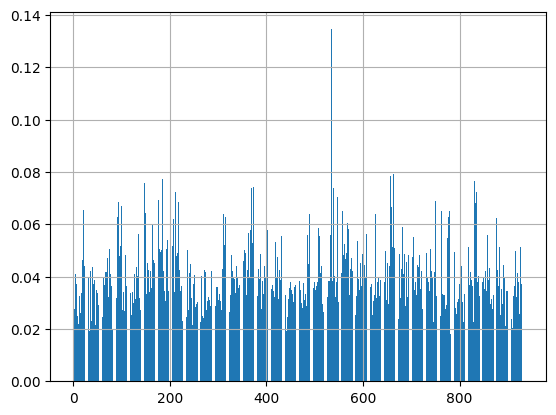

In [76]:
if recompute:
    # Merge everything
    DATA = wind_features.merge(
        turbulence_per_landing.rename("turbulence"),
        on="landing_id")
    DATA.to_csv("DATA%s.csv" %limit,index=False)
else:
    DATA = pd.read_csv("DATA%s.csv" %limit)

X = DATA.drop(columns=["landing_id","turbulence"])
y = DATA["turbulence"]

plt.bar(DATA["landing_id"],DATA["turbulence"])
plt.grid()

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [78]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test,y_pred)**0.5)

R²: 0.12635386128200665
RMSE: 0.01130077902321623


In [79]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(25))

                                   feature  importance
8           W04.ScalarMaxWindSpeed_30m_max    0.081994
26               W04.LastWindSpeed_30m_max    0.055540
15   W04.ScalarWindSpeedDeviation_30m_mean    0.052063
145              W04.LastWindSpeed_10m_std    0.040242
68          W04.ScalarMaxWindSpeed_20m_max    0.027355
17    W04.ScalarWindSpeedDeviation_30m_max    0.025490
75   W04.ScalarWindSpeedDeviation_20m_mean    0.018626
56               W22.LastWindSpeed_30m_max    0.016412
55               W22.LastWindSpeed_30m_std    0.015321
133        W04.ScalarMeanWindSpeed_10m_std    0.013884
57          W22.LastWindDirection_30m_mean    0.013702
38          W22.ScalarMaxWindSpeed_30m_max    0.013503
155    W22.VectorMeanWindDirection_10m_max    0.013227
106   W22.ScalarWindSpeedDeviation_20m_std    0.013148
95     W22.VectorMeanWindDirection_20m_max    0.011426
41    W22.ScalarMaxWindAtDirection_30m_max    0.011126
65     W04.VectorMeanWindDirection_20m_max    0.010894
108   W22.